In [2]:
#coding=utf-8
# ------------------------------------------------------------------------------------------#
# 
#-------------------------------------------------------------------------------------------#
from netCDF4 import Dataset as ncfile
from netCDF4 import num2date, date2num
import ast
import xarray as xr
from datetime import datetime, timedelta
import os, fnmatch, glob
import numpy as np
import numpy.ma as ma
import pandas as pd
import math
import matplotlib.dates as dates
from pyproj import Proj, transform
import scipy
from scipy import spatial
import cartopy.crs as ccrs
import cmocean
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

/home/maltem/.local/lib/python3.10/site-packages/pandas/core/arrays/masked.py:62: UserWarning: Pandas requires version '1.3.4' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


### 1 - Evaluation, conditional = SIC, leadtime 13-24h 

In [35]:
# Define start and end date
start_date = datetime(2024, 4, 6)  # 
end_date = datetime(2024, 4, 30)    # 

pls=13;ple=25
pls=37;ple=48

condvar = 'TS'

models = ['ECMWF-IFS' 'ECMWF-AIFS', 'DWD-ICON', 'MET-AROMEArctic', 'MF-AROME', 'MF-ARPEGE']

df = pd.read_csv('/lustre/storeB/users/maltem/SALIENSEAS/SvalMIZ2024/tmpcalc/MODISeval_'+condvar+'_'+str(pls)+'-'+str(ple)+'.csv')

df['RMSE'] = df['RMSE'].apply(lambda x: np.fromstring(x.strip('[]'), sep=' '))
df['Bias'] = df['Bias'].apply(lambda x: np.fromstring(x.strip('[]'), sep=' '))

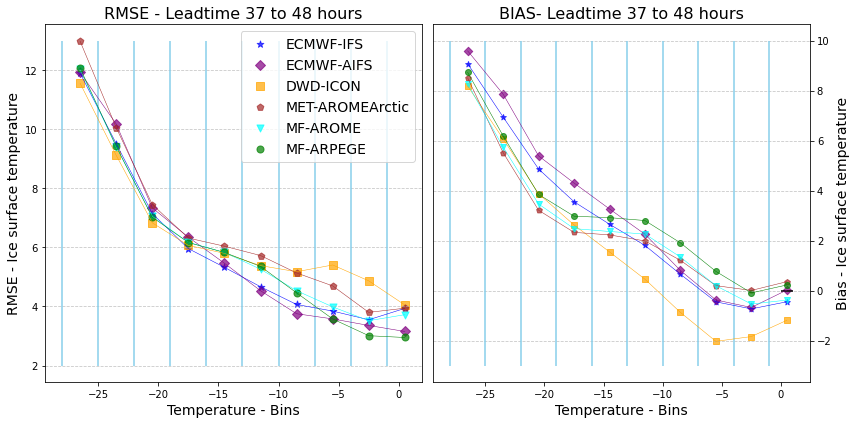

In [36]:
import matplotlib.pyplot as plt
import numpy as np

bins = np.arange(0.0, 1.2, 0.2)
bin_midpoint = bins[0:5] + 0.1
colorvec =['blue','purple','orange','brown','cyan','green']
markervec=['*','D','s','p','v','o']

if condvar=='SIC':
    xlabstring = 'Sea-Ice Concentration - Bins'
    ylabstring = 'Ice surface temperature'
    yminRMSE = 4; ymaxRMSE = 9
    yminBIAS = -2; ymaxBIAS = 5
    ymin = 5
    ymax = 8
    cmax=1;cmin=0;cinc=0.2
elif condvar=='TS':
    xlabstring = 'Temperature - Bins'
    ylabstring = 'Ice surface temperature'
    yminRMSE = 2; ymaxRMSE = 13
    yminBIAS = -3; ymaxBIAS = 10
    cmax=2; cmin=-28; cinc=3
    
    
    
if pls==13:
    fcrange = "13 to 24 hours"
elif pls==25:
    fcrange = "24 to 36 hours"
elif pls==37:
    fcrange = "37 to 48 hours"
    
bins = np.arange(cmin, cmax, cinc)
bin_midpoint = bins[0:len(bins)] + cinc/2.

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), sharey=False)

# Left: RMSE Plot
ax1.vlines(bins, ymin=yminRMSE, ymax=ymaxRMSE, colors='skyblue', linestyles='solid')

ii=0
for model in ['ECMWF-IFS', 'ECMWF-AIFS', 'DWD-ICON', 'MET-AROMEArctic', 'MF-AROME', 'MF-ARPEGE']:    
    i=int(np.array(list(df[df['Model'] == model].index)))    
    ax1.scatter(bin_midpoint, np.array(df.RMSE[i]), color=colorvec[ii], label=df.Model[i], s=50,marker=markervec[ii], alpha=0.7)   
    ax1.plot(   bin_midpoint, np.array(df.RMSE[i]), color=colorvec[ii], linewidth=0.5)
    ii=ii+1
    
ax1.set_xlabel(xlabstring, fontsize=14)
ax1.set_ylabel("RMSE - "+ylabstring, fontsize=14)
ax1.grid(axis='y', linestyle='--', alpha=0.7)
ax1.legend(fontsize=14)
ax1.set_title("RMSE - Leadtime "+fcrange, fontsize=16)

# Right: BIAS Plot
ax2.vlines(bins, ymin=yminBIAS, ymax=ymaxBIAS, colors='skyblue', linestyles='solid')
ax2.hlines(0., xmin=0, xmax=1, colors='black', linestyles='solid')
ii=0
for model in ['ECMWF-IFS', 'ECMWF-AIFS', 'DWD-ICON', 'MET-AROMEArctic', 'MF-AROME', 'MF-ARPEGE']:
    i=int(np.array(list(df[df['Model'] == model].index)))
    ax2.scatter(bin_midpoint, df.Bias[i], color=colorvec[ii], label=df.Model[i], marker=markervec[ii], alpha=0.7)  
    ax2.plot(   bin_midpoint, np.array(df.Bias[i]), color=colorvec[ii], linewidth=0.5)
    ii=ii+1
    
ax2.set_xlabel(xlabstring, fontsize=14)
ax2.set_title("BIAS- Leadtime "+fcrange, fontsize=16)
ax2.grid(axis='y', linestyle='--', alpha=0.7)
ax2.yaxis.tick_right()  # Move y-axis ticks to the right
ax2.yaxis.set_label_position("right")  # Move y-axis label to the right
ax2.set_ylabel("Bias - "+ylabstring, fontsize=14)
#ax2.legend(fontsize=10)

# Adjust layout and display
plt.tight_layout()
plt.savefig('MODISeval_'+condvar+'_'+str(pls)+'-'+str(ple)+'.png', format="png", dpi=300)  # Specify file name, format, and resolution

plt.show()


In [15]:
df.Model=='ECMWF-IFS'

0     True
1    False
2    False
3    False
4    False
5    False
Name: Model, dtype: bool

#### Some test environment

In [17]:
index_list = 
print(index_list)

[1]
